# An Introduction to FEAST v3.1

FEAST v3.1 is the Decemeber 2020 release of the Fugitive Emmissions Abatement Simulation Toolkit (FEAST). The toolkit simulates emissions from natural gas fields and the efficacy of leak detection and repair programs. This tutorial gives an example of how to generate an example emissions scenario in FEAST 3.1, define LDAR programs and analyze results. The tutorial is interactive, so feel free to experiment with the code cells and discover how your changes affect the results.

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import os
import copy
import feast
import pickle
from multiprocessing import Pool

# Defining an emission scenario
FEAST requires all potential emission sources to be declared as Components. Components are characterized by their emission production rate, emission size distribution, and the fraction of components expected to be emitting at the beginning of the simulation. In order to improve transparency, FEAST 3.1 does not have a "default" scenario. All emitters must be defined directly in order to run the simulation.

## Define fugitive components
For this example, we will define exactly one type of component: a fugitive emitter. Additional types of components can be created in the same way. Venting components (that is, components that are intended to produce emissions) can be created by setting the "base_reparable" variable to False. In real production sites vented and fugitive emissions will both be present.

In [112]:
comp_fug = feast.EmissionSimModules.infrastructure_classes.Component(
    name='Fugitive emitters',
    emission_data_path='ExampleData/DataObjectInstances/production_emissions.p',
    emission_per_comp=0.00231,  # Fraction of components expected to be emitting at the beginning of the simulation.
    # emission_production_rate is set to about 5 new emissions per well per year
    emission_production_rate=5.4 / 650 / 365,  # number of new emissions per component per day
    repair_cost_path='ExampleData/DataObjectInstances/fernandez_leak_repair_costs_2006.p',
    base_reparable=True
)

## Define a production Site
A site is made of a collection of components. The components are stored in the variable comp_dict. The analyst may include many component types in the comp_dict.

Using the copy library is good practice if a component type is going to be reused in multiple sites to avoid shared parameters.

In [113]:
wells_per_site = 2
comps_per_well = 650
basic_site = feast.EmissionSimModules.infrastructure_classes.Site(
    name='basic site',
    comp_dict={
        # ------ The number of components is proportional to the number of wells, ind2
        'Fugitive ': {'number': comps_per_well * wells_per_site,
                     'parameters': copy.deepcopy(comp_fug)},
    },
)

## Define a Time object
FEAST requires the simulation time settings to be declared in a time object.

In [114]:
time = feast.EmissionSimModules.simulation_classes.Time(delta_t=1, end_time=365)

## Define a GasField
All of the sites to be simulated must be collected into a dict and then passed to a GasField object. As of FEAST 3.1, a GasField object may also contain meteorological data.

In [115]:
site_dict = {
    'basic site': {
        'number': 100, # The number of basic_site instances to simulate in the gas_field
        'parameters': basic_site
    }
    # If additional site types are needed, they should be added here as separate dict entries
}
gas_field = feast.EmissionSimModules.infrastructure_classes.GasField(
    sites=site_dict,
    time=time,
    met_data_path='ExampleData/TMY-DataExample.csv'
)

# Define LDAR programs
LDAR programs are made of detection methods, repair methods, and the connections between them. The first step in creating LDAR programs is defining detection and repair methods.

## Define a repair method
A repair method takes one input parameter: the delay (days) between when an emission is detected and when it is repaired.

In [116]:
rep3 = feast.DetectionModules.repair.Repair(repair_delay=3)

## Define detection methods
Detection methods accept a variety of variables that depend on the type of detection method to be simulated. In all cases, a detection method requires a set of conditions to be specified where the probability of detection (PoD) is known. Three examples are demonstrated below.

In [117]:
# An OGI-like example where the PoD depends on emission rate only.
def make_ogi(dispatch_obj):
    points = np.array([0.5, 1, 2, 3, 7]) * 0.01157 # g/s
    probs = np.array([0, 0.25, 0.5, 0.75, 1])
    ogi = feast.DetectionModules.comp_survey.CompSurvey(
        time,
        survey_interval=180, # days
        survey_speed=500, # comps/hr
        ophrs={'begin': 8, 'end': 17},
        labor=400, # $/hr
        detection_variables={'flux': 'mean'},
        detection_probability_points=points,  # g/s
        detection_probabilities=probs,
        dispatch_object=copy.deepcopy(dispatch_obj),
        site_queue=[],
    )
    return ogi
ogi = make_ogi(rep3)

In [118]:
# An OGI-like example that does not automatically survey components but can be dispatched
def make_ogi_no_survey(dispatch_obj):
    points = np.array([0.5, 1, 2, 3, 7]) * 0.01157 # g/s
    probs = np.array([0, 0.25, 0.5, 0.75, 1])
    ogi_no_survey = feast.DetectionModules.comp_survey.CompSurvey(
        time,
        survey_interval=None, # days
        survey_speed=500, # comps/hr
        ophrs={'begin': 8, 'end': 17},
        labor=400, # $/hr
        detection_variables={'flux': 'mean'},
        detection_probability_points=points,  # g/s
        detection_probabilities=probs,
        dispatch_object=copy.deepcopy(dispatch_obj),
        site_queue=[],
    )
    return ogi_no_survey
ogi_no_survey = make_ogi_no_survey(rep3)

In [119]:
# A site level survey method
def make_plane_survey(dispatch_obj):
    points = np.array([25, 50, 100, 200, 400]) * 0.01157 # g/s
    probs = np.array([0, 0.25, 0.5, 0.75, 1])
    plane_survey = feast.DetectionModules.site_survey.SiteSurvey(
        time,
        survey_interval=180, # days
        sites_per_day=200,
        site_cost=100, # $/site
        detection_variables={'flux': 'mean'},
        detection_probability_points=points,
        detection_probabilities=probs,
        dispatch_object=copy.deepcopy(dispatch_obj),
        site_queue=[],
        ophrs={'begin': 8, 'end': 17}
    )
    return plane_survey
plane_survey = make_plane_survey(ogi_no_survey)

In [120]:
# Continuous monitor method where detection depends on emission rate and windspeed. 
def make_cont_monitor(dispatch_obj):
    points = [[0.5, 1], 
              [1.0, 1], 
              [1.1, 1], 
              [0.5, 5], 
              [1.0, 5], 
              [1.1, 5],
              [0.5, 5.1], 
              [1.0, 5.1],
              [1.1, 5.1]]
    time_to_detect_days = [np.inf, 1, 0, np.inf, 5, 0, np.inf, np.inf, np.inf]
    cont_monitor = feast.DetectionModules.site_monitor.SiteMonitor(
        time,
        time_to_detect_points=points,
        time_to_detect_days=time_to_detect_days,
        detection_variables={'flux': 'mean', 'wind speed': 'mean'},
        site_queue=list(range(gas_field.n_sites)),
        dispatch_object=copy.deepcopy(dispatch_obj),
        ophrs={'begin': 8, 'end': 17}
    )
    return cont_monitor
cont_monitor = make_cont_monitor(ogi_no_survey)

## Collect detection methods into LDARPrograms

In [121]:
# Define LDAR programs
ogi_survey = feast.DetectionModules.ldar_program.LDARProgram(
    copy.deepcopy(gas_field), {'ogi': copy.deepcopy(ogi)},
)
# tiered survey
tech_dict = {
    'plane': plane_survey,
    'ogi': plane_survey.dispatch_object
}
plane_ogi_survey = feast.DetectionModules.ldar_program.LDARProgram(
    copy.deepcopy(gas_field), tech_dict,
)

# continuous monitor
tech_dict = {
    'cm': cont_monitor,
    'ogi': cont_monitor.dispatch_object
}
cm_ogi = feast.DetectionModules.ldar_program.LDARProgram(
    copy.deepcopy(gas_field), tech_dict,
)

# All programs
ldar_dict = {
    # Note: continuous monitor simulations dominate the computation load.
    # Comment out the next line to exclude the continuous monitor program from the simulation.
    'cm': cm_ogi,
    'ogi': ogi_survey,
    'plane': plane_ogi_survey
}


# Run simulation

In [122]:
scenario = feast.EmissionSimModules.simulation_classes.Scenario(time=time, 
                                                                gas_field=gas_field, 
                                                                ldar_program_dict=ldar_dict)
scenario.run(dir_out='TutorialResults', display_status=True, save_method='json')

The evaluation is 0% complete
The evaluation is 10% complete
The evaluation is 20% complete
The evaluation is 30% complete
The evaluation is 40% complete
The evaluation is 50% complete
The evaluation is 60% complete
The evaluation is 70% complete
The evaluation is 80% complete
The evaluation is 90% complete


Okay - we have the initial simulation run and saved in json. So lets look at that data + see about plotting. 
I had to modify slightly; the original python notebook didn't include the continuous monitoring in the json save, which is real dumb. 

In [125]:
import json
realn = len(os.listdir('TutorialResults')) - 2
with open('TutorialResults/realization' +str(realn) + '.json') as f:
    runresults = json.load(f)

In [143]:
runresults.keys()

dict_keys(['cm', 'ogi', 'plane', 'Null', 'time'])

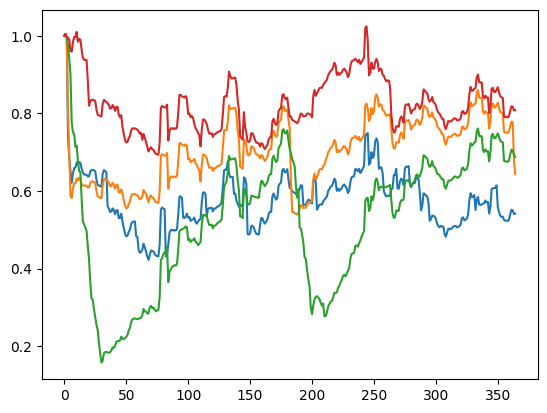

In [134]:
timesteps = np.array(range(0, runresults['time']['end_time']))
ems_cm = np.array(runresults['cm']['emission timeseries']) / runresults['Null']['emission timeseries'][0]
ems_pln = np.array(runresults['plane']['emission timeseries']) / runresults['Null']['emission timeseries'][0]
ems_ogi = np.array(runresults['ogi']['emission timeseries']) / runresults['Null']['emission timeseries'][0]
ems_null = np.array(runresults['Null']['emission timeseries']) / runresults['Null']['emission timeseries'][0]
plt.plot(timesteps, ems_cm)
plt.plot(timesteps, ems_pln)
plt.plot(timesteps, ems_ogi)
plt.plot(timesteps, ems_null)
plt.show()

Okay, that's good - very basic plot of the emissions timeseries from the modeling. Lets see about functionalizing that? 
First - extremely basic loop to pull out the program names: 

In [137]:
counter = 0 
for i in runresults.keys():
    print(i)
    counter += 1

cm
ogi
plane
Null
time


Okay, that's good - we can loop over the different programs and pull out the emissions timeseries. I'm adapting the code in the FEAST plotting; lets see how it goes. 
Note: you need to print plt.legend() to get the legend to work. https://stackoverflow.com/questions/11983024/matplotlib-legends-not-working
you do the average plots in a non-array because you only need two points for each line, start and ending. 

cm
ogi
plane
no LDAR


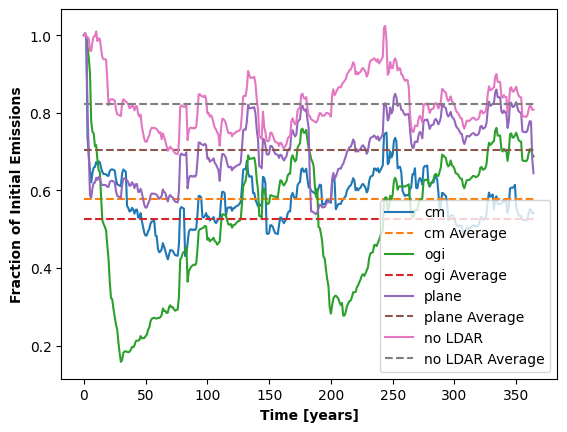

In [188]:
fig = plt.figure()
ax = fig.add_subplot(111)

 
for i in runresults.keys():
    lab = i #set the legend 
    #skip time and also set null to no LDAR
    if i.lower() == "null":
        lab = "no LDAR"
    if i.lower() == "time":
        break
    print(lab)
    ax.plot(np.array(range(0,runresults['time']['n_timesteps'])), 
            np.array(runresults[i]['emission timeseries']) / runresults["Null"]['emission timeseries'][0], 
            label=lab)
    
    avg_emissions = np.mean(np.array(runresults[i]['emission timeseries'])  / runresults["Null"]['emission timeseries'][0])
    ax.plot([0,runresults['time']['n_timesteps']],np.array([avg_emissions, avg_emissions]), '--', label = lab + ' Average')

    

plt.xlabel('Time [years]', fontweight = 'bold')
plt.ylabel('Fraction of Initial Emissions', fontweight = 'bold')
plt.legend(bbox_to_anchor=(1, 0.72))
plt.legend()

Okay, cool. So we have some plotting abilities here with the timeseries; lets try and sort out some additional ways at getting at this dataset. Lets look in the continuous monitoring subset:  

In [189]:
runresults["cm"].keys()

dict_keys(['emission timeseries', 'vent timeseries', 'repair cost', 'cm', 'ogi', 'ogi repair'])

In [194]:
timesteps = np.array(range(0, runresults['time']['end_time']))
cm_rc = np.array(runresults['cm']['ogi repair']['repair cost'])